In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# Load and combine all city CSVs
files = glob.glob('../data/raw/*.csv')
dfs = []
for f in files:
    city = f.split('/')[-1].replace('.csv', '')
    tmp = pd.read_csv(f)
    tmp['City'] = city
    dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)
print(df.shape)

(32963, 41)


In [4]:
# 1. Nulls & dtypes
print(df.isnull().sum())
print(df.dtypes)

Price                  0
Area                   0
Location               0
No. of Bedrooms        0
Resale                 0
MaintenanceStaff       0
Gymnasium              0
SwimmingPool           0
LandscapedGardens      0
JoggingTrack           0
RainWaterHarvesting    0
IndoorGames            0
ShoppingMall           0
Intercom               0
SportsFacility         0
ATM                    0
ClubHouse              0
School                 0
24X7Security           0
PowerBackup            0
CarParking             0
StaffQuarter           0
Cafeteria              0
MultipurposeRoom       0
Hospital               0
WashingMachine         0
Gasconnection          0
AC                     0
Wifi                   0
Children'splayarea     0
LiftAvailable          0
BED                    0
VaastuCompliant        0
Microwave              0
GolfCourse             0
TV                     0
DiningTable            0
Sofa                   0
Wardrobe               0
Refrigerator           0


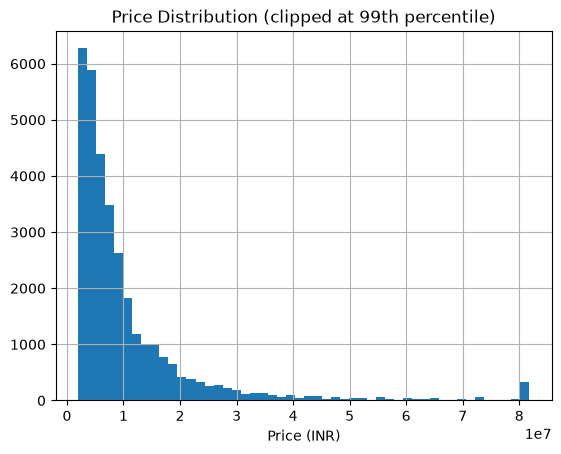

In [5]:
# 2. Target distribution (Price)
df['Price'].clip(upper=df['Price'].quantile(0.99)).hist(bins=50)
plt.title('Price Distribution (clipped at 99th percentile)')
plt.xlabel('Price (INR)')
plt.show()

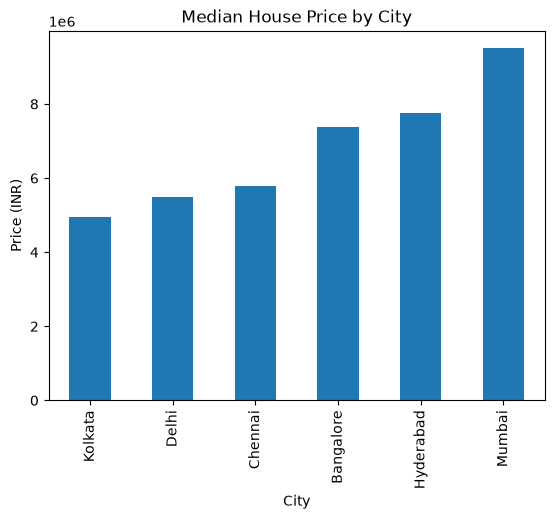

In [6]:
# 3. Average price by City
df.groupby('City')['Price'].median().sort_values().plot(kind='bar')
plt.title('Median House Price by City')
plt.ylabel('Price (INR)')
plt.show()

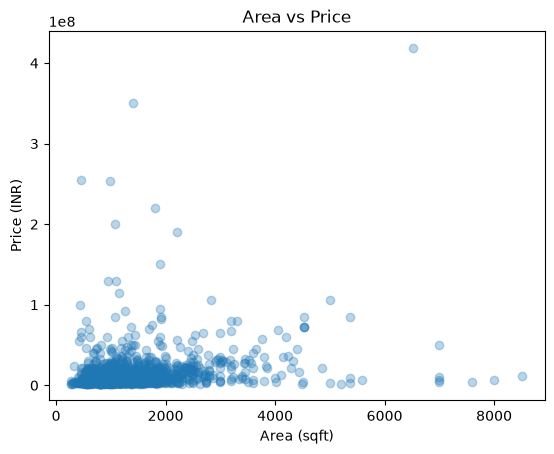

In [7]:
# 4. Area vs Price scatter
sample = df.sample(2000, random_state=42)
plt.scatter(sample['Area'], sample['Price'], alpha=0.3)
plt.title('Area vs Price')
plt.xlabel('Area (sqft)')
plt.ylabel('Price (INR)')
plt.show()

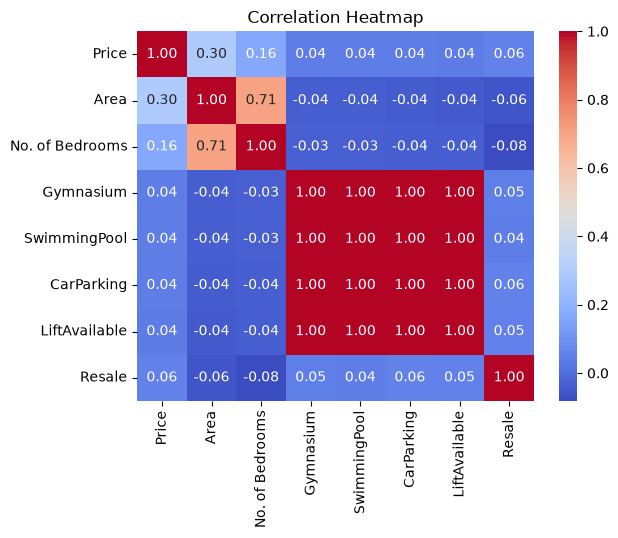

In [8]:
# 5. Correlation heatmap
features = ['Price', 'Area', 'No. of Bedrooms', 'Gymnasium', 'SwimmingPool',
            'CarParking', 'LiftAvailable', 'Resale']
sns.heatmap(df[features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [9]:
# Final: select features & target, save sample
features = ['Area', 'Location', 'No. of Bedrooms', 'Resale', 'MaintenanceStaff',
            'Gymnasium', 'SwimmingPool', 'LiftAvailable', 'CarParking', 'City']
target = 'Price'

df_model = df[features + [target]].dropna()
print(df_model.shape)

df_model.sample(5000, random_state=42).to_csv('../data/raw/sample.csv', index=False)
print('sample.csv saved')
df_model.head()

(32963, 11)
sample.csv saved


,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LiftAvailable,CarParking,City,Price
0,1016,Barasat,3,0,0,1,1,1,0,Kolkata,2235000
1,1111,Keshtopur,2,0,1,1,0,0,0,Kolkata,3665999
2,1020,Rajarhat,2,0,0,1,0,1,0,Kolkata,3774000
3,935,Narendrapur,2,0,0,1,1,0,0,Kolkata,2524000
4,1956,New Town,3,1,0,1,1,1,1,Kolkata,8300000
